**Helper code to generate some images for the handling outliers, noise and overlapping in the housing example analysis report**

NOTE! See the df.query for quantile filtering for this example (below code cell). Due to heavy outliers in the high-price houses, there was some difficulties in creating clear images in the later stages.

In [2]:
import pandas as pd

# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../houses.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)

# since price is a continuous variable, it's not practical to use it 
# in some of the visualizations. binning creates a categorical variable
# out of a continuous variable, allowing us the use it in visualizations
# this example bins the price into five categories

# in this dataset, there's some outliers of expensive houses on the high end
# that makes it difficult to compare categories
# this example removes the top 2% houses to make it easier to read the following charts
df = df.query('price < price.quantile(q=0.98)')

# for easier visualizations, we'll split the continuous price into categories
df['binned_price'] = pd.cut(df['price'], bins=5, labels=['Low', 'Below Average', 'Average', 'Above Average', 'High'])

<Axes: xlabel='sqft_living', ylabel='price'>

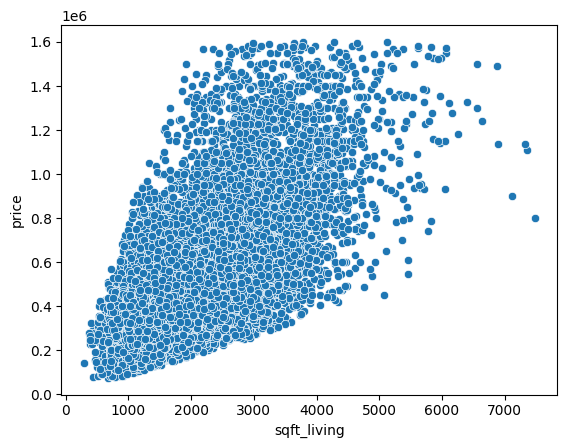

In [3]:
# checking the outliers for large buildings and price
# it seems the largest buildings are actually not the most expensive ones, but they are expensive.
sns.scatterplot(data=df, x="sqft_living", y="price")

**It roughly seems sqft_living and price are connected, however, some outliers to the right (extremely large houses that often are very expensive)**

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_3560\4209673076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binned_price', y='grade', data=df, palette='coolwarm')


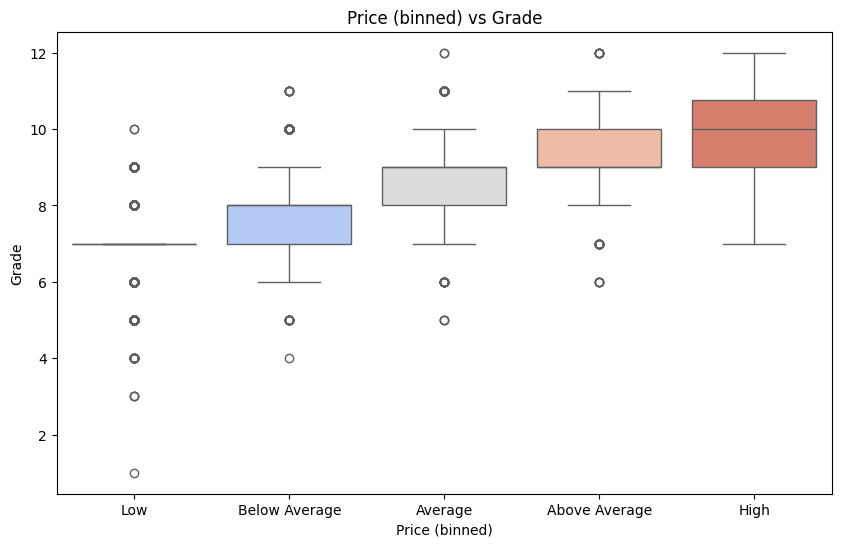

In [4]:
# compare binned price to grade
plt.figure(figsize=(10, 6))
sns.boxplot(x='binned_price', y='grade', data=df, palette='coolwarm')
plt.title('Price (binned) vs Grade')
plt.xlabel('Price (binned)')
plt.ylabel('Grade')
plt.show()

**It seems the price tends to rice as grade goes up.**

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_3560\41277931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binned_price', y='bathrooms', data=df, palette='coolwarm')


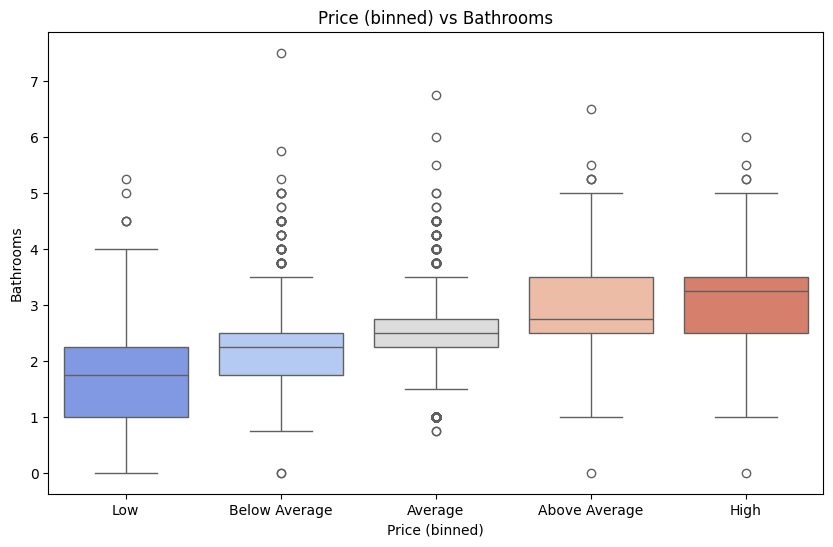

In [5]:
# compare binned price to bathrooms
plt.figure(figsize=(10, 6))
sns.boxplot(x='binned_price', y='bathrooms', data=df, palette='coolwarm')
plt.title('Price (binned) vs Bathrooms')
plt.xlabel('Price (binned)')
plt.ylabel('Bathrooms')
plt.show()

**There's a mild trend of price going up when there are more bathrooms... however, it's a bit noisy / has outliers.**

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_3560\316603334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binned_price', y='bedrooms', data=df, palette='coolwarm')


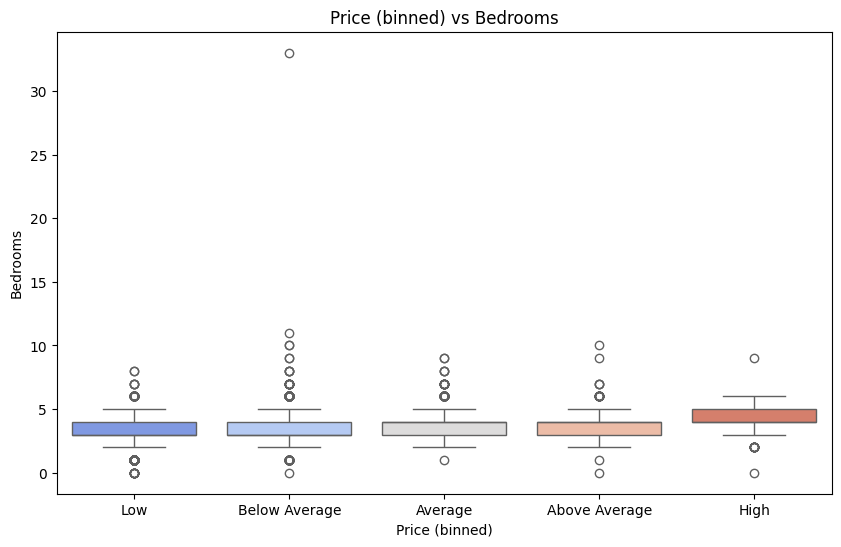

In [6]:
# compare binned price to bedrooms
plt.figure(figsize=(10, 6))
sns.boxplot(x='binned_price', y='bedrooms', data=df, palette='coolwarm')
plt.title('Price (binned) vs Bedrooms')
plt.xlabel('Price (binned)')
plt.ylabel('Bedrooms')
plt.show()

**It seems amount of bedrooms doesn't really affect the price...howver, there's a slight increase to the most expensive houses (most expensive houses tend to have quite many bedrooms)**

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_3560\686437933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binned_price', y='condition', data=df, palette='coolwarm')


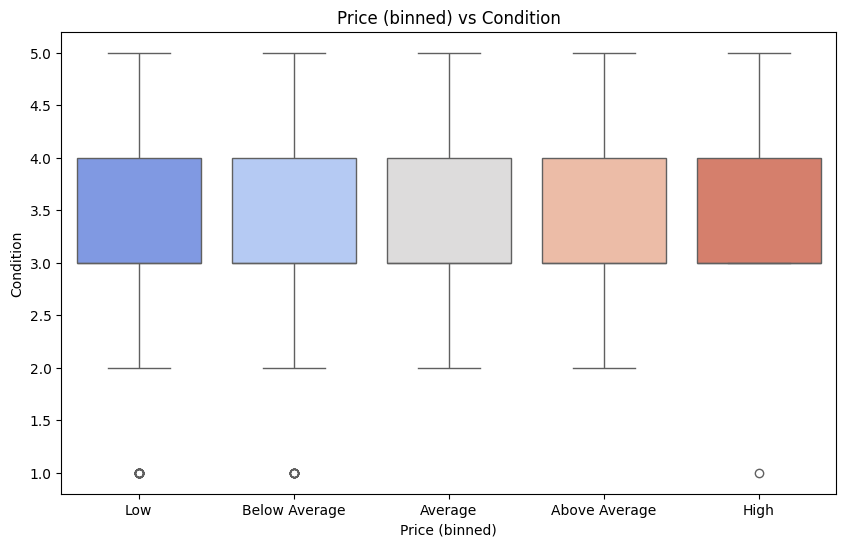

In [13]:
# compare binned price to condition
plt.figure(figsize=(10, 6))
sns.boxplot(x='binned_price', y='condition', data=df, palette='coolwarm')
plt.title('Price (binned) vs Condition')
plt.xlabel('Price (binned)')
plt.ylabel('Condition')
plt.show()

**The condition seems to have no effect on price, as we originally suspected.**

### Overlapping detecting with seaborn scatterplots!

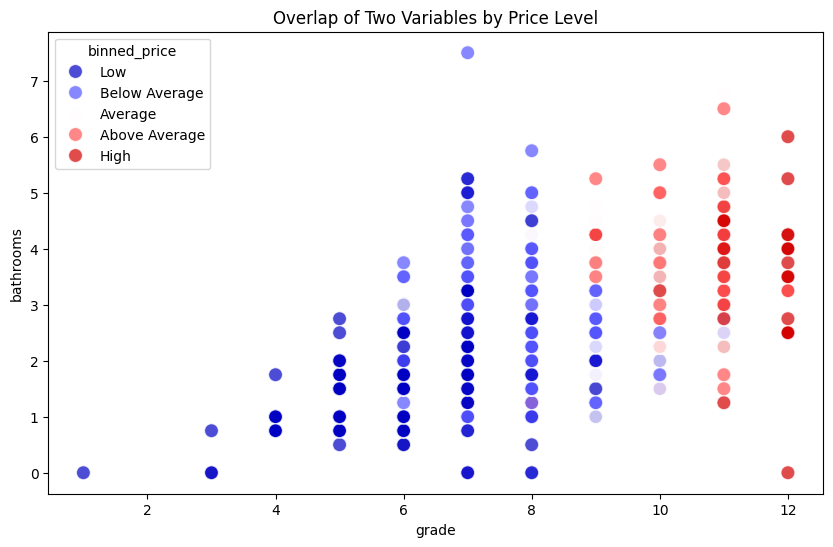

In [8]:
# Plot setup
plt.figure(figsize=(10, 6))
sns.scatterplot(x='grade', y='bathrooms', hue='binned_price', data=df, palette='seismic', s=100, alpha=0.7)

# Add title and labels
plt.title('Overlap of Two Variables by Price Level')
plt.xlabel('grade')
plt.ylabel('bathrooms')

# Display the plot
plt.show()

**The data is divided quite nicely... cheap houses have lower grade, expensive houses have higher grade (sligh over lap between grades 9-10)**

This is good news for a machine learning model!

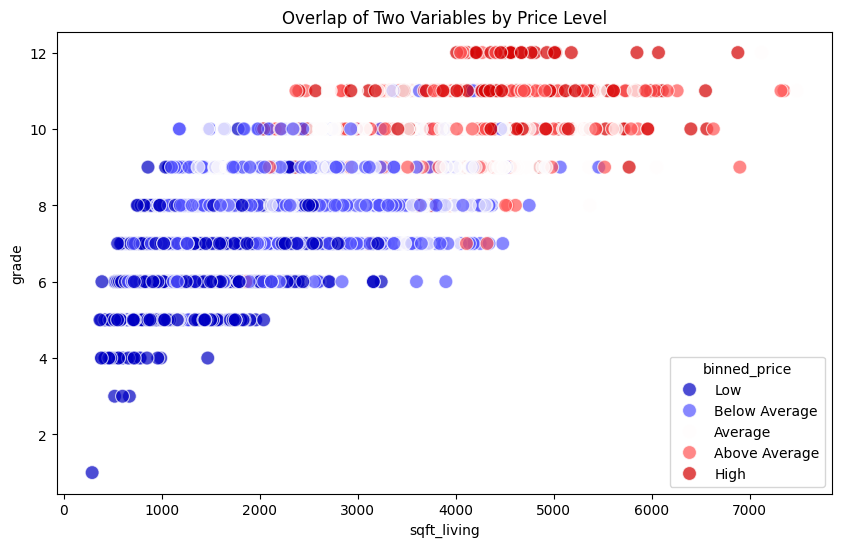

In [9]:
# Plot setup
plt.figure(figsize=(10, 6))

sns.scatterplot(x='sqft_living', y='grade', hue='binned_price', data=df, palette='seismic', s=100, alpha=0.7)

# Add title and labels
plt.title('Overlap of Two Variables by Price Level')
plt.xlabel('sqft_living')
plt.ylabel('grade')

# Display the plot
plt.show()

**Fairly clean division between small and big houses, good!**

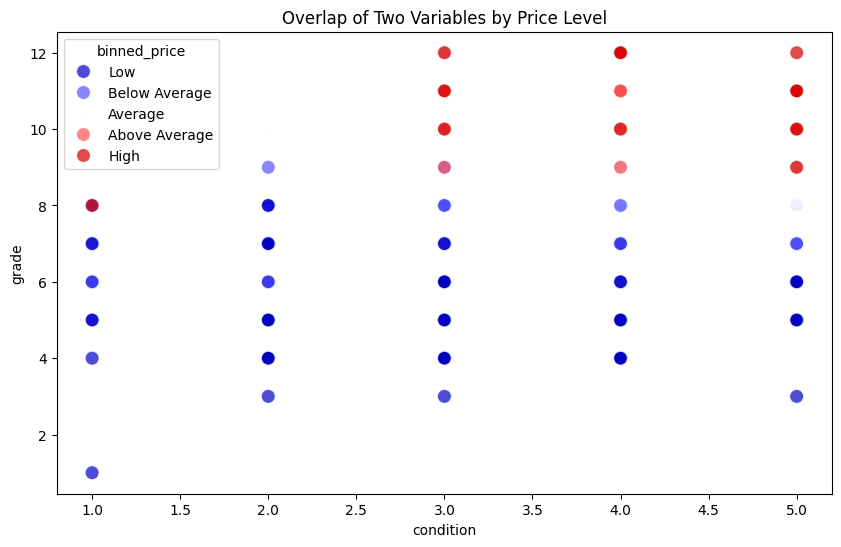

In [10]:
# Plot setup
plt.figure(figsize=(10, 6))
sns.scatterplot(x='condition', y='grade', hue='binned_price', data=df, palette='seismic', s=100, alpha=0.7)

# Add title and labels
plt.title('Overlap of Two Variables by Price Level')
plt.xlabel('condition')
plt.ylabel('grade')

# Display the plot
plt.show()

**The condition is all over the place, the condition can be anything regardless of grade.**

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_3560\3455035774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="binned_price", y='view', data=df, palette='seismic')


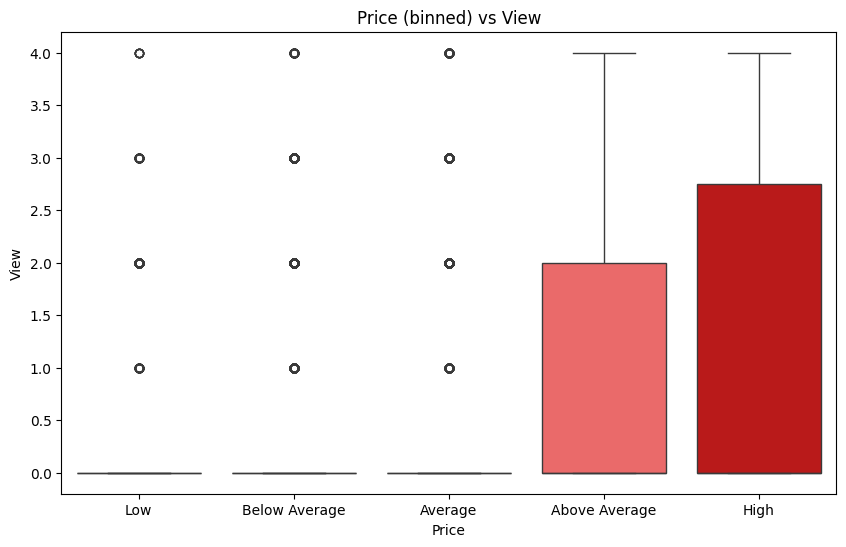

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="binned_price", y='view', data=df, palette='seismic')
plt.title('Price (binned) vs View')
plt.xlabel('Price')
plt.ylabel('View')
plt.show()

**Let's check the view too... it seems view starts to affect the price in the more expensive houses (makes sense, luxurious homes tend to have amazing views...?)**

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_3560\1711117382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="binned_price", y='waterfront', data=df, palette='seismic')


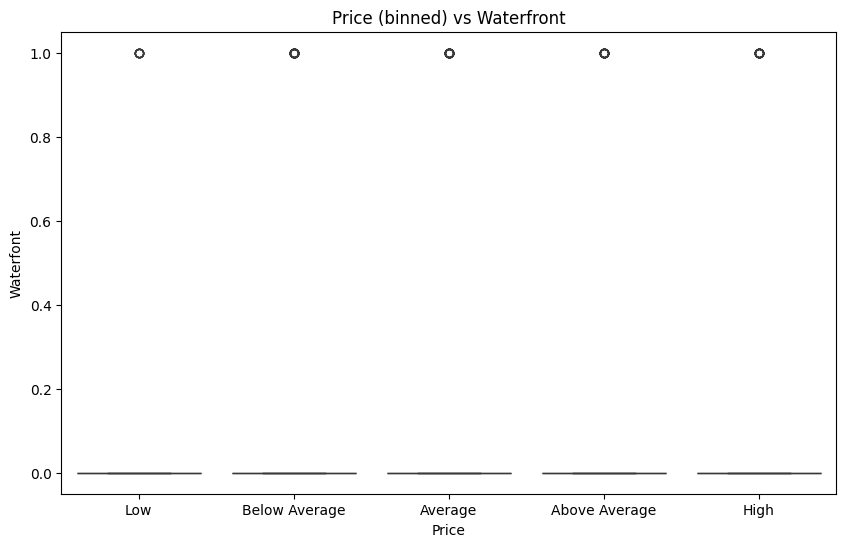

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="binned_price", y='waterfront', data=df, palette='seismic')
plt.title('Price (binned) vs Waterfront')
plt.xlabel('Price')
plt.ylabel('Waterfont')
plt.show()

**Not much to see when it comes to waterfront. Probably due to the reason that we have very little data of houses next to water.**